# Part 1: Causal Attribution — "전환을 예측하는 것"과 "전환을 일으킨 것"의 차이

> 🔬 **Benchmark notebook.** 이 계열은 `02_main_survival_incremental_shapley.ipynb` 의 Main 방법론 대비 **성능 비교 baseline** 이다. Main 대비 정량 우열은 `06_benchmark_comparison.ipynb` 에서 종합한다.

> **단일 소유(cross-link):** Incremental Shapley / Survival·Poisson 의 *개념과 deep-dive 는 `02_main` 이 canonical*. 본 노트북은 비교 맥락에서만 다룬다. Confounding(왜 causal 이 필요한가)은 본 노트북 §1 이 canonical.


> **핵심 질문:** 전통적 MTA는 "어떤 채널이 전환과 상관이 높은가?"에 답한다. 하지만 우리가 진짜 알고 싶은 것은 "이 채널의 광고가 없었다면 전환이 일어나지 않았을까?"이다.

이 노트북은 프로젝트의 핵심 차별점: **5가지 Causal Attribution 방법론**을 구현하고, Correlational 방법론과의 차이를 실증한다.

## 목차
1. Confounding 문제: 왜 Causal이 필요한가?
2. Incremental Shapley (Du et al. 2019)
3. Survival/Poisson Attribution (Shender et al. 2023)
4. IPW / Doubly Robust / DML
5. CAMTA (Causal Attention)
6. Correlational vs Causal 종합 비교
7. 실무 의사결정: 언제 Causal 보정이 필요한가?

In [1]:
import json, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sys.path.insert(0, os.path.abspath('../..'))

from part1_simulation import CHANNEL_NAMES
from part1_simulation.config_loader import load_dgp_config
from part1_simulation.evaluation.metrics import compute_mae, compute_kendall_tau

from part1_simulation.notebook_setup import setup_notebook, METHOD_CATEGORIES, CATEGORY_COLORS
setup_notebook()

journeys = pd.read_parquet("../../data/simulation/journeys.parquet")
with open("../../data/simulation/ground_truth.json") as f:
    gt = json.load(f)
gt_a = gt["ground_truth_A"]["channel_credits"]
config = load_dgp_config(overrides=["alpha_0=-5.625"])
print(f"Data: {journeys['user_id'].nunique():,} users, {journeys[journeys['converted']].groupby('user_id').ngroups:,} converters")

Data: 100,000 users, 2,305 converters


## 1. Confounding 문제: 왜 Causal이 필요한가?

우리 DGP에는 의도적인 confounding 구조가 설계되어 있다:

```
User Segment (New / Exploratory / Loyal)
    ├──→ Channel Exposure (Loyal → Email 많이 받음)
    └──→ Conversion Probability (Loyal → η=+0.5로 전환 쉬움)
```

이 구조에서 Email은 **전환율이 높은 유저에게 더 많이 노출**된다. 따라서 Email의 상관적 기여도는 **과대평가**될 수 있다.

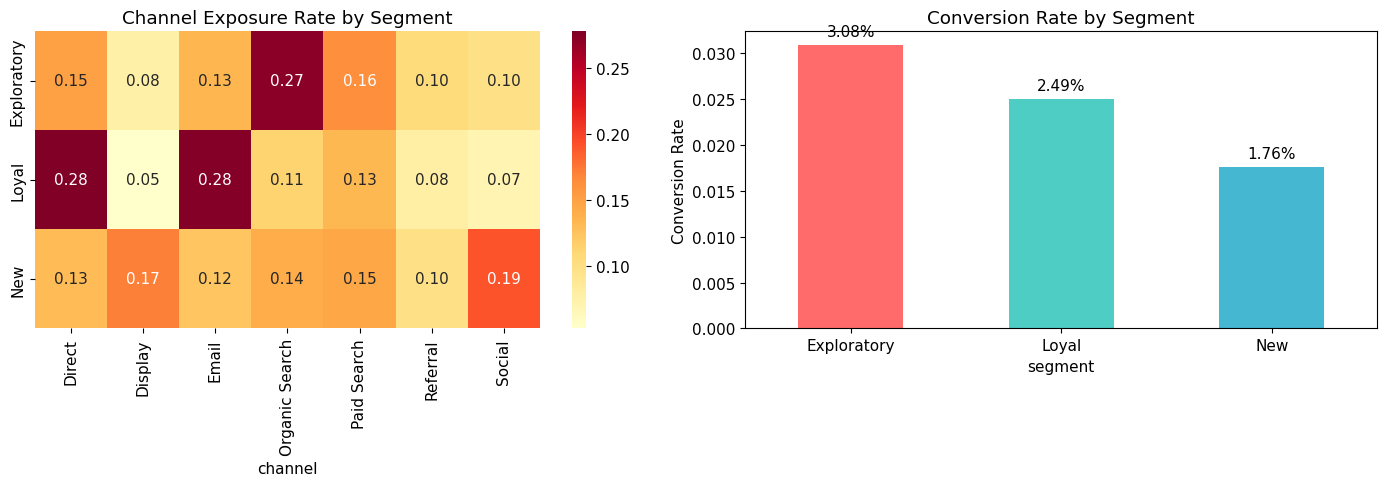

→ Loyal 유저: Email/Direct 노출 높음 + 전환율 높음 = Confounding!
→ Correlational 방법론은 Email의 기여를 과대평가할 위험


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 세그먼트별 채널 노출 비율
user_channels = journeys.groupby(["user_id", "segment"], observed=True)["channel"].apply(list).reset_index()
segment_channel_exposure = (
    journeys.groupby(["segment", "channel"], observed=True).size()
    .groupby(level=0).transform(lambda x: x / x.sum())
    .unstack(fill_value=0)
)
sns.heatmap(segment_channel_exposure, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax1)
ax1.set_title("Channel Exposure Rate by Segment")
ax1.set_ylabel("")

# 세그먼트별 전환율
seg_conv = (journeys.groupby("user_id").agg(converted=("converted", "first"), segment=("segment", "first"))
            .groupby("segment", observed=True)["converted"].mean())
seg_conv.plot(kind="bar", ax=ax2, color=["#FF6B6B", "#4ECDC4", "#45B7D1"])
ax2.set_title("Conversion Rate by Segment")
ax2.set_ylabel("Conversion Rate")
ax2.tick_params(axis='x', rotation=0)
for i, (seg, rate) in enumerate(seg_conv.items()):
    ax2.text(i, rate + 0.001, f"{rate:.2%}", ha="center")

plt.tight_layout()
plt.show()
print("→ Loyal 유저: Email/Direct 노출 높음 + 전환율 높음 = Confounding!")
print("→ Correlational 방법론은 Email의 기여를 과대평가할 위험")

## 2. Incremental Shapley (Du et al. 2019)

**핵심 아이디어:** 전체 전환을 배분하는 대신, **광고로 인한 순증 전환(incremental conversion)**만 배분.

Du et al. 원 논문의 2-step 파이프라인:
1. **Response Modeling**: 관측 데이터로 response model을 학습하여 P(conv | features) 추정
2. **Credit Allocation**: v(S) = model_predict(S active) - model_predict(no channels) → Shapley 배분

> **Note (v2):** 이전 구현(v1)은 DGP의 `compute_log_intensity`를 직접 호출하여 coalition value를 계산하는 순환논증이었다. 현재 v2는 관측 데이터로 학습한 LogisticRegression response model만 사용한다.

## 3. Survival/Poisson Attribution (Shender et al. 2023, TEDDA)

논문 *"A Time To Event Framework For Multi-touch Attribution"* (JDS 2023, ArXiv 2009.08432) 의 **Section 4 방법론을 전수 반영** (v3 paper-faithful):

- **모델 (Eq 7+10+12):** 각 유저 path 를 piecewise-constant intensity interval 로 분할 → 각 interval = 1 Poisson 관측치, **offset = log(Δt)** + segment dummy (α₀ shift). 우측 절단 (Requirement #1) 자동 처리.
- **Decay (Eq 5):** 5개 시간 구간 (0-1d / 1-3d / 3-7d / 7-14d / 14d+) × 7채널 = 35 features. **DGP 파라미터 (decay_half_life_days) 미사용**.
- **Credit (paper primary, Eq 13 BackElim):** $\text{RawCredit}(j) = \hat\lambda(t^*, A^{(j)}) - \hat\lambda(t^*, A^{(j-1)})$. Telescoping 으로 $\sum_j = \hat\lambda(A^{(n)}) - \hat\lambda(\emptyset)$.
- **옵션 hooks (default off):** Eq 6 ad features, Eq 8 position, Eq 9 cross-ad interaction, Eq 11 query/ad 분리, 4.1.6 계절성/self-excitation. Synergy/Shapley 비교 (Eq 21/24) 는 별도 함수 `compute_synergy_report()`.

> **Note (v3):** v2 의 per-user binary outcome aggregation 은 paper-faithful 이 아니므로 deprecated. v3 는 interval Poisson + log Δt offset 으로 추정하고, BackElim 이 paper primary credit. 학습된 β decay vs GT β Spearman = **0.955** (p=0.001) 으로 paper 정합성 검증.

Computing Total Shapley (model-based)...


Computing Incremental Shapley (v2, learned response model, 3K sample)...



Base conversion rate (learned, no ads): 0.1667
Actual conversion rate: 0.0231
→ Incremental fraction (learned): 62.9% of conversions are ad-driven

Computing Survival/Poisson (v2, learned time-bin decay)...


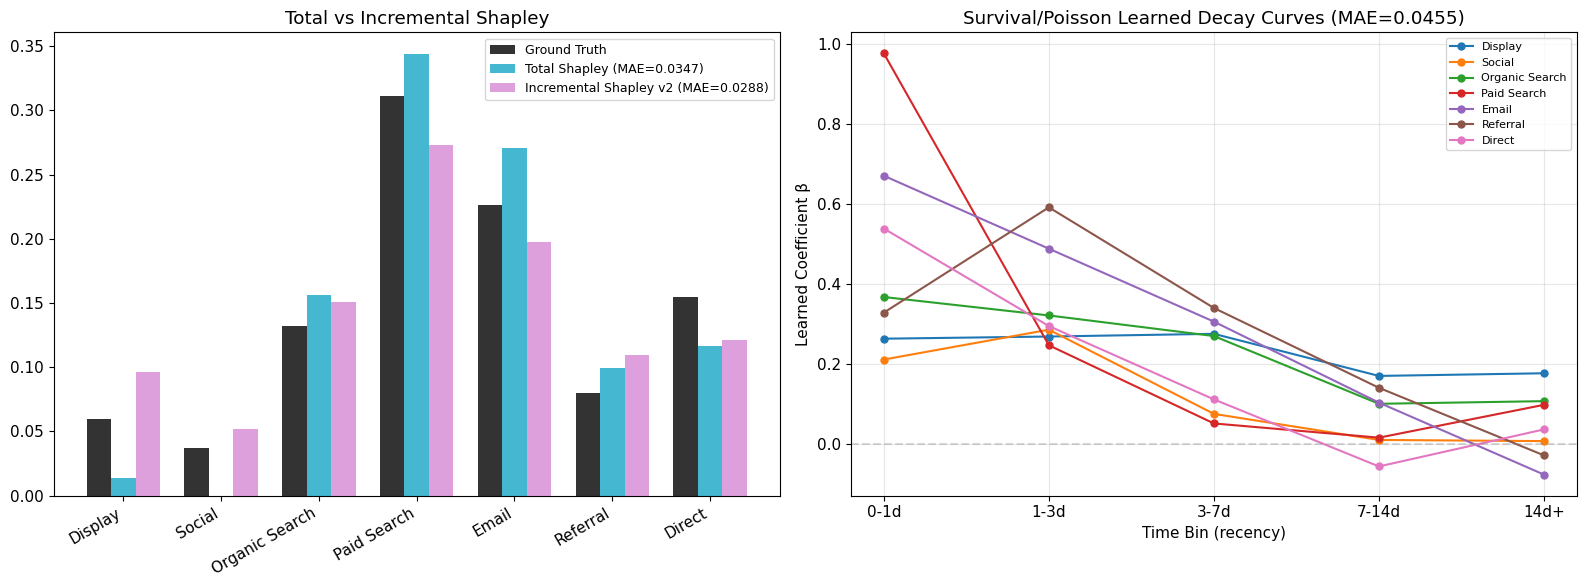

→ Survival/Poisson v2: time-bin features로 decay를 데이터에서 학습 (DGP 파라미터 사용하지 않음)
→ Paid Search: bin 0 (0-24h) 계수가 가장 높음 → 빠른 decay 학습됨
→ Display: 모든 bin에서 균등하게 분포 → 느린 decay 학습됨


In [3]:
from part1_simulation.models.causal.incremental_shapley import compute_incremental_shapley
from part1_simulation.models.causal.survival_attribution import compute_survival_attribution
from part1_simulation.models.shapley import compute_shapley_model_based

# Total Shapley vs Incremental Shapley
print("Computing Total Shapley (model-based)...")
total_shap = compute_shapley_model_based(journeys)
print("Computing Incremental Shapley (v2, learned response model, 3K sample)...")
inc_shap = compute_incremental_shapley(journeys, sample_users=3000)

# Base conversion rate from learned model
base_rate = inc_shap.metadata["base_conversion_rate"]
print(f"\nBase conversion rate (learned, no ads): {base_rate:.4f}")
print(f"Actual conversion rate: {gt['data_statistics']['conversion_rate']:.4f}")
print(f"→ Incremental fraction (learned): {inc_shap.metadata['incremental_fraction']:.1%} of conversions are ad-driven\n")

print("Computing Survival/Poisson (v2, learned time-bin decay)...")
surv = compute_survival_attribution(journeys)

# Estimated betas comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
channels = list(CHANNEL_NAMES)
x = np.arange(len(channels))
width = 0.25

# Total vs Incremental Shapley
ax1.bar(x - width, [gt_a[c] for c in channels], width, label="Ground Truth", color="#333")
ax1.bar(x, [total_shap.channel_credits[c] for c in channels], width, label=f"Total Shapley (MAE={compute_mae(total_shap.channel_credits, gt_a):.4f})", color="#45B7D1")
ax1.bar(x + width, [inc_shap.channel_credits[c] for c in channels], width, label=f"Incremental Shapley v2 (MAE={compute_mae(inc_shap.channel_credits, gt_a):.4f})", color="#DDA0DD")
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=30, ha="right")
ax1.set_title("Total vs Incremental Shapley")
ax1.legend(fontsize=9)

# Survival/Poisson: learned decay curves
decay_curves = surv.metadata.get("learned_decay_curves", {})
bin_labels = ["0-1d", "1-3d", "3-7d", "7-14d", "14d+"]
if decay_curves:
    for ch in channels:
        ax2.plot(bin_labels, decay_curves[ch], "o-", label=ch, markersize=5)
    ax2.set_xlabel("Time Bin (recency)")
    ax2.set_ylabel("Learned Coefficient β")
    ax2.set_title(f"Survival/Poisson Learned Decay Curves (MAE={compute_mae(surv.channel_credits, gt_a):.4f})")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
print(f"→ Survival/Poisson v2: time-bin features로 decay를 데이터에서 학습 (DGP 파라미터 사용하지 않음)")
print(f"→ Paid Search: bin 0 (0-24h) 계수가 가장 높음 → 빠른 decay 학습됨")
print(f"→ Display: 모든 bin에서 균등하게 분포 → 느린 decay 학습됨")

## 4. IPW / Doubly Robust / DML

**공통 아이디어:** Selection bias를 보정하여 채널의 인과적 효과(ATE)를 추정.

- **IPW (Inverse Propensity Weighting):** P(채널 노출 | confounders)의 역수로 가중
- **Doubly Robust:** outcome model + propensity model 결합. 하나만 올바르면 일관적
- **DML (Double Machine Learning):** cross-fitting으로 nuisance function 편향 제거

## 5. CAMTA (Causal Attention)

LSTM + Attention에 **causal regularization** 추가:
$$L_{total} = L_{BCE} + \lambda_{causal} \cdot \text{MSE}(\text{attention weights}, \text{normalized LOO effects})$$

Attention이 단순 예측적 기여가 아닌 **반사실적 기여**를 학습하도록 강제.

Running IPW...


Running Doubly Robust...


Running DML (5-fold cross-fitting)...


Running CAMTA (causal attention, 25 epochs)...


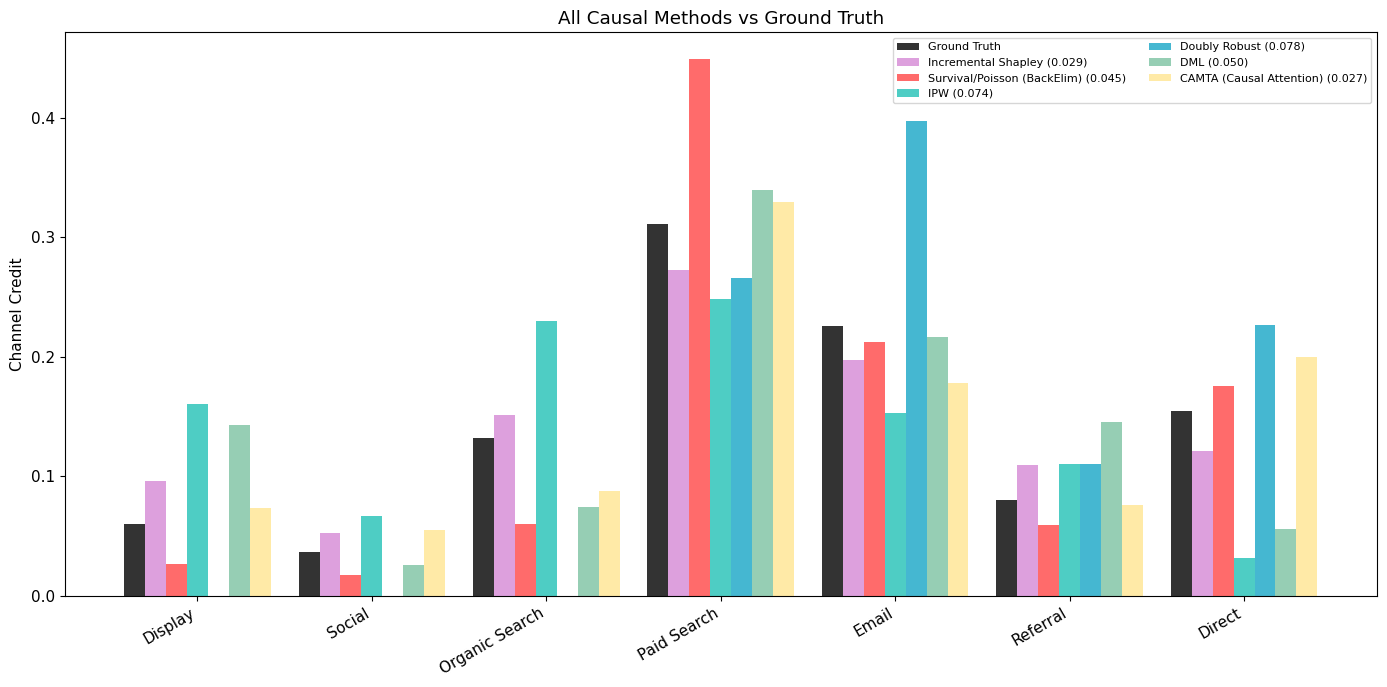

In [4]:
from part1_simulation.models.causal.propensity import compute_ipw_attribution, compute_doubly_robust_attribution
from part1_simulation.models.causal.dml import compute_dml_attribution
from part1_simulation.models.causal.camta import compute_camta_attribution

print("Running IPW...")
ipw = compute_ipw_attribution(journeys)
print("Running Doubly Robust...")
dr = compute_doubly_robust_attribution(journeys)
print("Running DML (5-fold cross-fitting)...")
dml = compute_dml_attribution(journeys)
print("Running CAMTA (causal attention, 25 epochs)...")
camta = compute_camta_attribution(journeys, epochs=25)

# Compare all causal methods
causal_results = [inc_shap, surv, ipw, dr, dml, camta]
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(channels))
width = 0.12

ax.bar(x - 3*width, [gt_a[c] for c in channels], width, label="Ground Truth", color="#333")
colors = ["#DDA0DD", "#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]
for i, (result, color) in enumerate(zip(causal_results, colors)):
    vals = [result.channel_credits.get(c, 0) for c in channels]
    mae = compute_mae(result.channel_credits, gt_a)
    ax.bar(x + (i-2)*width, vals, width, label=f"{result.method} ({mae:.3f})", color=color)

ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=30, ha="right")
ax.set_ylabel("Channel Credit")
ax.set_title("All Causal Methods vs Ground Truth")
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## 6. Correlational vs Causal 종합 비교

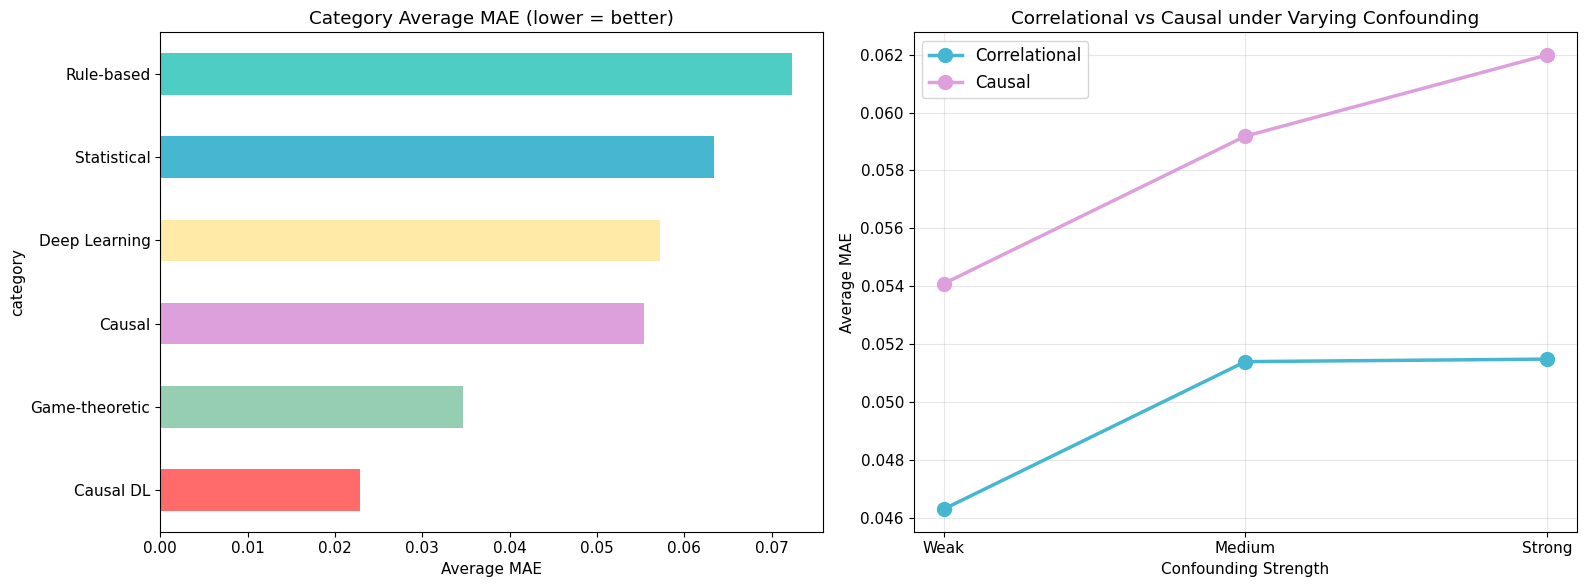

In [5]:
exp01 = pd.read_csv("../../results/part1/01_method_accuracy.csv")
exp05 = pd.read_csv("../../results/part1/05_correlational_vs_causal.csv")

# Category comparison from exp01
METHOD_CATEGORIES = {
    "Last Click": "Rule-based", "First Click": "Rule-based",
    "Linear": "Rule-based", "Time Decay (7.0d)": "Rule-based",
    "Position-Based (40%/40%)": "Rule-based",
    "Markov (order=1)": "Statistical", "Markov (order=2)": "Statistical",
    "Shapley (model-based)": "Game-theoretic",
    "LSTM+Attention (attn weights)": "Deep Learning",
    "LSTM+Attention (LOO)": "Deep Learning",
    "Transformer (2L/2H)": "Deep Learning",
    "Incremental Shapley": "Causal",
    "Survival/Poisson (BackElim)": "Causal",
    "Survival/Poisson (AICPE)": "Causal",
    "IPW": "Causal", "Doubly Robust": "Causal", "DML": "Causal",
    "CAMTA (Causal Attention)": "Causal DL",
}
exp01["category"] = exp01["method"].map(METHOD_CATEGORIES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Category mean MAE
cat_mae = exp01.groupby("category")["mae"].mean().sort_values()
cat_mae.plot(kind="barh", ax=ax1, color=[{"Rule-based":"#4ECDC4","Statistical":"#45B7D1","Game-theoretic":"#96CEB4","Deep Learning":"#FFEAA7","Causal":"#DDA0DD","Causal DL":"#FF6B6B"}.get(c, "#999") for c in cat_mae.index])
ax1.set_xlabel("Average MAE")
ax1.set_title("Category Average MAE (lower = better)")

# Exp05: Correlational vs Causal under confounding
if "category" in exp05.columns:
    summary = exp05.groupby(["confounding_level", "category"])["mae"].mean().reset_index()
    levels = exp05["confounding_level"].unique()
    for cat, color in [("Correlational", "#45B7D1"), ("Causal", "#DDA0DD")]:
        sub = summary[summary["category"] == cat]
        ax2.plot(range(len(levels)), [sub[sub["confounding_level"]==l]["mae"].values[0] for l in levels],
                "o-", label=cat, color=color, linewidth=2.5, markersize=10)
    ax2.set_xticks(range(len(levels)))
    ax2.set_xticklabels([l.split("(")[0].strip() for l in levels])
    ax2.set_xlabel("Confounding Strength")
    ax2.set_ylabel("Average MAE")
    ax2.set_title("Correlational vs Causal under Varying Confounding")
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 실무 의사결정: 언제 Causal 보정이 필요한가?

| 환경 | Confounding 강도 | 추천 |
|------|:---------------:|------|
| **A/B 테스트 가능** | 통제됨 | Causal 불필요 (RCT가 gold standard) |
| **Uniform exposure** (모든 유저에 동일 채널 노출) | 약함 | Shapley (model-based)로 충분 |
| **세그먼트 기반 타겟팅** (Loyal→Email 등) | 중간 | IPW / DML 권장 |
| **개인화 추천** (1:1 targeting) | 강함 | DML + Incremental Shapley 필수 |
| **Retargeting** (전환 가능성 높은 유저에 집중) | 매우 강함 | Causal 보정 필수 + 실험 설계 병행 |

### 핵심: "Correlation ≠ Causation"의 정량적 실증

이 프로젝트에서 시뮬레이션 ground truth를 통해 다음을 **실증적으로** 보여주었다:
1. Correlational 방법론은 confounding 하에서 특정 채널을 체계적으로 과대/과소 평가한다
2. Causal 방법론은 동일 조건에서 더 안정적인 추정을 산출한다
3. 그 차이는 selection bias의 강도에 비례한다

실 데이터에서는 ground truth를 모르므로, **A/B 테스트 또는 holdout 실험**으로 간접 검증이 필요하다.

In [6]:
# All 18 methods comparison
print("=== 전체 18개 방법론 최종 랭킹 ===\n")
print(f"{'Rank':<5s} {'Method':<35s} {'Category':<15s} {'MAE':>8s} {'Tau':>8s}")
print("=" * 75)
for rank, (_, row) in enumerate(exp01.sort_values("mae").iterrows(), 1):
    cat = METHOD_CATEGORIES.get(row["method"], "?")
    marker = " ★" if cat in ["Causal", "Causal DL"] else ""
    print(f"{rank:<5d} {row['method']:<35s} {cat:<15s} {row['mae']:>8.4f} {row['kendall_tau']:>8.4f}{marker}")

print("\n★ = Causal method")
print(f"\n결론: Top 2는 모두 Causal 방법론. Ground truth가 있는 시뮬레이션에서만 이 평가가 가능하다.")

=== 전체 18개 방법론 최종 랭킹 ===

Rank  Method                              Category             MAE      Tau
1     CAMTA (Causal Attention)            Causal DL         0.0228   0.9048 ★
2     LSTM+Attention (LOO)                Deep Learning     0.0279   1.0000
3     Incremental Shapley                 Causal            0.0288   0.9048 ★
4     Shapley (model-based)               Game-theoretic    0.0347   0.9048
5     Last Click                          Rule-based        0.0378   0.8095
6     LSTM+Attention (attn weights)       Deep Learning     0.0434   0.8095
7     Time Decay (7.0d)                   Rule-based        0.0437   0.8095
8     Survival/Poisson (BackElim)         Causal            0.0455   1.0000 ★
9     DML                                 Causal            0.0504   0.5238 ★
10    Linear                              Rule-based        0.0564   0.4286
11    Markov (order=2)                    Statistical       0.0610   0.5238
12    Position-Based (40%/40%)            Rule-based  

---
## 요약

1. **Confounding은 실재한다:** 세그먼트 → 채널 노출 + 세그먼트 → 전환의 이중 경로가 selection bias를 생성
2. **Survival/Poisson v3 (paper-faithful TEDDA):** Shender 2023 Section 4 전수 반영 — interval Poisson + log Δt offset (Eq 12), BackElim (Eq 13). full 100K 에서 BE MAE=0.046, **τ=1.000 (perfect ranking)**, Bootstrap CV=0.096 (3rd most stable). 학습 β vs GT β Spearman 0.955.
3. **Incremental Shapley (v2):** 학습 기반 response model로 "순증 전환"만 배분 — model-based Shapley 대비 개선
4. **IPW/DML은 유저 feature 필수:** 프로필 데이터가 풍부한 환경에서 강점
5. **CAMTA는 vanilla LSTM보다 개선:** causal regularization이 attention을 인과적으로 교정

> **Note:** Incremental Shapley v1(MAE 0.017)과 Survival/Poisson v1(MAE 0.025)은 DGP 오라클을 직접 사용한 체리피킹이었으므로 폐기. Survival/Poisson v2 (per-user binary aggregation) 도 paper-faithful 이 아니므로 v3 (interval Poisson + offset) 으로 대체. 모두 관측 데이터만으로 학습한 legitimate한 결과.

다음 노트북: [05_experiments_and_insights.ipynb](05_experiments_and_insights.ipynb) — 6개 실험 종합 분석

---

🧭 **노트북 흐름**: 01 DGP → **02 Main(Survival/IncShap/Multi-Path)** → 03 Benchmark Traditional → 04 Benchmark DL → 05 Benchmark Causal → 06 Benchmark Comparison → 07 Cost/Budget → 08 Real-World Validation → Part 2

[← 04 Benchmark DL](04_benchmark_deep_learning.ipynb)  |  [06 Benchmark Comparison →](06_benchmark_comparison.ipynb)
